<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_8_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8: Practice Notebook

**You do not need to submit this Notebook.** It is for practice only.

## Introduction to the Dataset

The Heart Failure Clinical Records dataset contains medical records of 299 patients who experienced heart failure. The dataset includes 12 clinical features measured during follow-up, such as age, blood test results, and presence of various conditions. While this dataset is often used for classification (predicting survival), we will use clustering to discover natural groupings of patients based on their clinical profiles.

### Goal
Explore and apply clustering algorithms - specifically **K-Means**, **DBSCAN**, and **Hierarchical Agglomerative Clustering** - to identify patient groups with similar clinical characteristics. Clustering is an unsupervised learning technique that finds patterns in data without predefined labels.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

from sklearn import cluster
from sklearn import compose
from sklearn import metrics
from sklearn import preprocessing

In [2]:
seed = 42

## Load and Explore the Data

We'll load the Heart Failure Clinical Records dataset directly from the UCI Machine Learning Repository.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)
df.shape

(299, 13)

Let's examine the structure and contents of the dataset. The data contains a mix of binary, integer, and continuous features representing various clinical measurements.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [5]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


For clustering, we don't use labeled data. In a real-world scenario, you would likely be using a dataset that does contain labeled data, as this dataset does. For the purpose of this tutorial, we will drop the `DEATH_EVENT` label column. We'll also check for null values.

In [6]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


## Preparing the Data

### Drop the Target Column

Since clustering is unsupervised, we remove the `DEATH_EVENT` column. However, we'll save it to evaluate clusters later.

In [7]:
death_event = df["DEATH_EVENT"]

X = df.drop(columns="DEATH_EVENT")
X.shape

(299, 12)

### Preprocessing with ColumnTransformer

Clustering algorithms are sensitive to feature scales. Since we have some binary features (which are either 0 or 1), we'll use MinMaxScaler to scale all features between 0 and 1.

As we saw, this dataset has no missing values and all features are already numeric, so our preprocessing is straightforward.

In [8]:
transformer = compose.make_column_transformer(
    (
        preprocessing.MinMaxScaler(),
        compose.make_column_selector(dtype_include=np.number)
    ),
    verbose_feature_names_out=False
)

X_scaled_array = transformer.fit_transform(X)

Converting the scaled data back to a DataFrame helps with readability and debugging.

In [9]:
columns = transformer.get_feature_names_out()
X_scaled = pd.DataFrame(X_scaled_array, columns=columns)
X_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,0.636364,0.0,0.071319,0.0,0.090909,1.0,0.290823,0.157303,0.485714,1.0,0.0,0.000000
1,0.272727,0.0,1.000000,0.0,0.363636,0.0,0.288833,0.067416,0.657143,1.0,0.0,0.007117
2,0.454545,0.0,0.015693,0.0,0.090909,0.0,0.165960,0.089888,0.457143,1.0,1.0,0.010676
3,0.181818,1.0,0.011227,0.0,0.090909,0.0,0.224148,0.157303,0.685714,1.0,0.0,0.010676
4,0.454545,1.0,0.017479,1.0,0.090909,0.0,0.365984,0.247191,0.085714,0.0,0.0,0.014235


In [10]:
X_scaled.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000
mean,0.378798,0.431438,0.071299,0.418060,0.364903,0.351171,0.288833,0.100436,0.675012,0.648829,0.32107,0.449327
std,0.216269,0.496107,0.123793,0.494067,0.179316,0.478136,0.118565,0.116237,0.126071,0.478136,0.46767,0.276207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.200000,0.000000,0.011929,0.000000,0.242424,0.000000,0.227179,0.044944,0.600000,0.000000,0.00000,0.245552
50%,0.363636,0.000000,0.028961,0.000000,0.363636,0.000000,0.287186,0.067416,0.685714,1.000000,0.00000,0.395018
75%,0.545455,1.000000,0.071319,1.000000,0.469697,1.000000,0.337495,0.101124,0.771429,1.000000,1.00000,0.708185
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


## K-Means Clustering

K-Means is a clustering algorithm that partitions data into K distinct clusters. Each data point belongs to the cluster with the nearest mean (centroid). The algorithm iteratively updates cluster centroids until convergence.

### Understanding K-Means Parameters

- **n_clusters**: The number of clusters to form. This is the most important parameter and must be specified.
- **n_init**: Number of times the algorithm runs with different centroid seeds. The best result is kept.
- **max_iter**: Maximum number of iterations for a single run.

In [11]:
kmeans = cluster.KMeans(
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=seed
)

kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_

Let's see how many patients are in each cluster.

In [12]:
pd.Series(labels_kmeans).value_counts().sort_index()

,count
0,77
1,117
2,105


### Finding the Optimal Number of Clusters

Here, we set a range of K values to compare.

In [13]:
k_range = range(2, 30)

The **Elbow Method** helps determine the optimal number of clusters. For each value of K, we plot the **inertia** of each model, which is the sum of the squared distances between each sample and their closest centroid.

The "elbow" point suggests a good K value where adding more clusters yields diminishing returns.

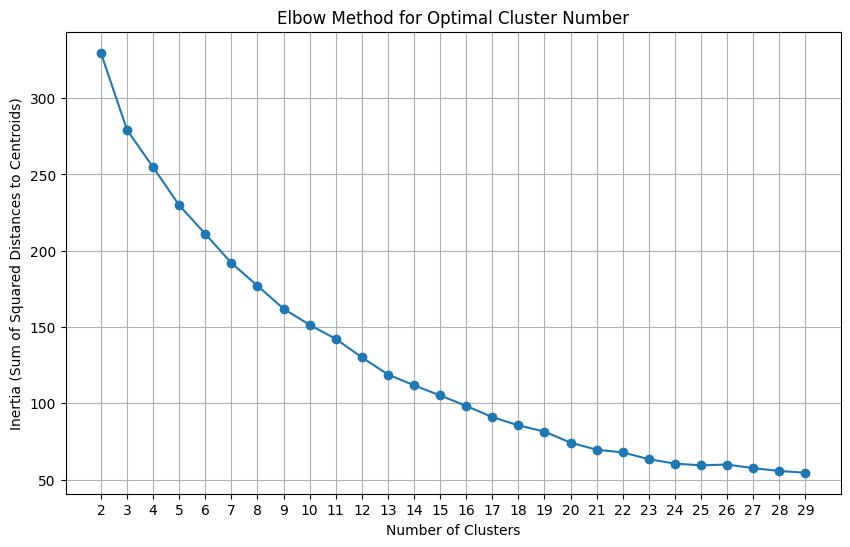

In [14]:
inertias = []

for k in k_range:
    km = cluster.KMeans(n_clusters=k, random_state=seed, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Sum of Squared Distances to Centroids)")
plt.title("Elbow Method for Optimal Cluster Number")
plt.xticks(k_range)
plt.grid(True)
plt.show()

Above, where do you think the elbow point is? It is not always clear, and in some cases there may be multiple possible selections.

We can get more precise with cluster evaluation using Silhouette Scores.

The **Silhouette Score** measures how similar each point is to its own cluster compared to other clusters. Values range from -1 to 1, where higher values indicate better-defined clusters.

k=2: Silhouette Score = 0.193
k=3: Silhouette Score = 0.205
k=4: Silhouette Score = 0.195
k=5: Silhouette Score = 0.206
k=6: Silhouette Score = 0.209
k=7: Silhouette Score = 0.242
k=8: Silhouette Score = 0.257
k=9: Silhouette Score = 0.280
k=10: Silhouette Score = 0.282
k=11: Silhouette Score = 0.286
k=12: Silhouette Score = 0.309
k=13: Silhouette Score = 0.325
k=14: Silhouette Score = 0.337
k=15: Silhouette Score = 0.344
k=16: Silhouette Score = 0.367
k=17: Silhouette Score = 0.383
k=18: Silhouette Score = 0.395
k=19: Silhouette Score = 0.406
k=20: Silhouette Score = 0.428
k=21: Silhouette Score = 0.442
k=22: Silhouette Score = 0.429
k=23: Silhouette Score = 0.429
k=24: Silhouette Score = 0.438
k=25: Silhouette Score = 0.422
k=26: Silhouette Score = 0.417
k=27: Silhouette Score = 0.418
k=28: Silhouette Score = 0.409
k=29: Silhouette Score = 0.397


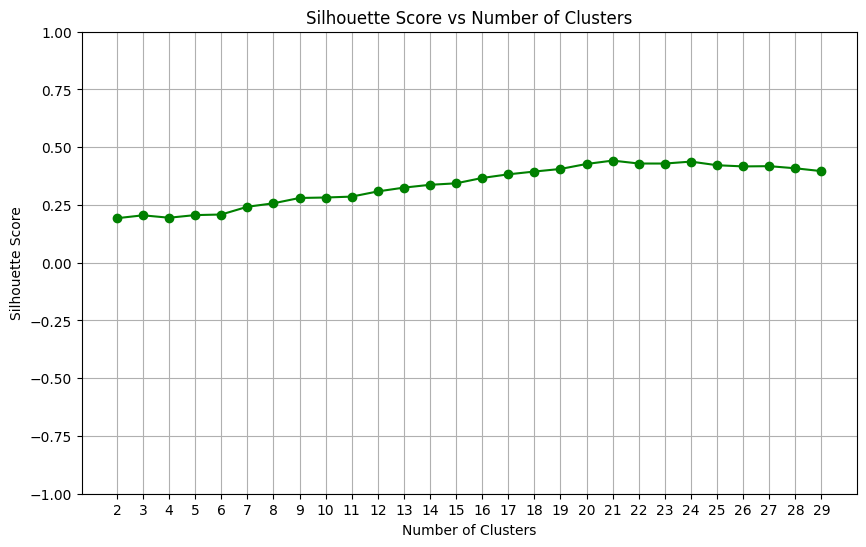

In [15]:
silhouette_scores = []

for k in k_range:
    km = cluster.KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = metrics.silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker="o", color="green")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_range)
plt.ylim(-1, 1)
plt.grid(True)
plt.show()

## DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm. Unlike K-Means, it doesn't require specifying the number of clusters beforehand and can find clusters of arbitrary shape. It also identifies outliers as noise points.

### Understanding DBSCAN Parameters

- **eps** (epsilon): The maximum distance between two samples for them to be considered neighbors. Smaller values create more clusters.
- **min_samples**: The minimum number of samples in a neighborhood for a point to be a core point. Larger values create fewer, denser clusters.

In [16]:
dbscan = cluster.DBSCAN(
    eps=0.5,
    min_samples=5,
)

labels_dbscan = dbscan.fit_predict(X_scaled)

In DBSCAN, points labeled as -1 are considered noise (outliers). Let's see how many clusters were found.

In [17]:
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"\nCluster distribution:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

Number of clusters: 22
Number of noise points: 37

Cluster distribution:
-1     37
 0     29
 1     16
 2     11
 3      8
 4     12
 5      8
 6      9
 7      6
 8     17
 9     12
 10    15
 11     8
 12    10
 13    14
 14    12
 15    12
 16    18
 17    15
 18     5
 19    12
 20     5
 21     8
Name: count, dtype: int64


### Tuning DBSCAN Parameters

Finding good eps and min_samples values requires experimentation. Let's try different eps values to see how they affect clustering.

In [18]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]

for eps in eps_values:
    db = cluster.DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points")

eps=0.3: 5 clusters, 272 noise points
eps=0.5: 22 clusters, 37 noise points
eps=0.7: 22 clusters, 15 noise points
eps=1.0: 22 clusters, 11 noise points
eps=1.5: 1 clusters, 0 noise points


## Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method that builds a tree of clusters. It starts with each point as its own cluster and iteratively merges the closest pairs of clusters until reaching the desired number of clusters.

### Understanding Agglomerative Clustering Parameters

- **n_clusters**: The number of clusters to find.
- **linkage**: Determines how distance between clusters is calculated:
  - "ward": Minimizes variance within clusters
  - "complete": Uses maximum distance between cluster points
  - "average": Uses average distance between cluster points
  - "single": Uses minimum distance between cluster points

In [19]:
agg = cluster.AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_agg = agg.fit_predict(X_scaled)

In [20]:
pd.Series(labels_agg).value_counts().sort_index()

,count
0,92
1,112
2,95


### Comparing Different Linkage Methods

Different linkage methods can produce different cluster structures. Let's compare them using the Silhouette Score.

In [21]:
linkages = ["ward", "complete", "average", "single"]

for link in linkages:
    agg_model = cluster.AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg_model.fit_predict(X_scaled)
    score = metrics.silhouette_score(X_scaled, labels)
    print(f"Linkage={link}: Silhouette Score = {score:.3f}")

Linkage=ward: Silhouette Score = 0.172
Linkage=complete: Silhouette Score = 0.194
Linkage=average: Silhouette Score = 0.167
Linkage=single: Silhouette Score = 0.040


### Dendrogram Visualization

A dendrogram shows the hierarchical relationship between clusters. The height of each merge indicates the distance between clusters at that step. We'll visualize a subset of the data for clarity.

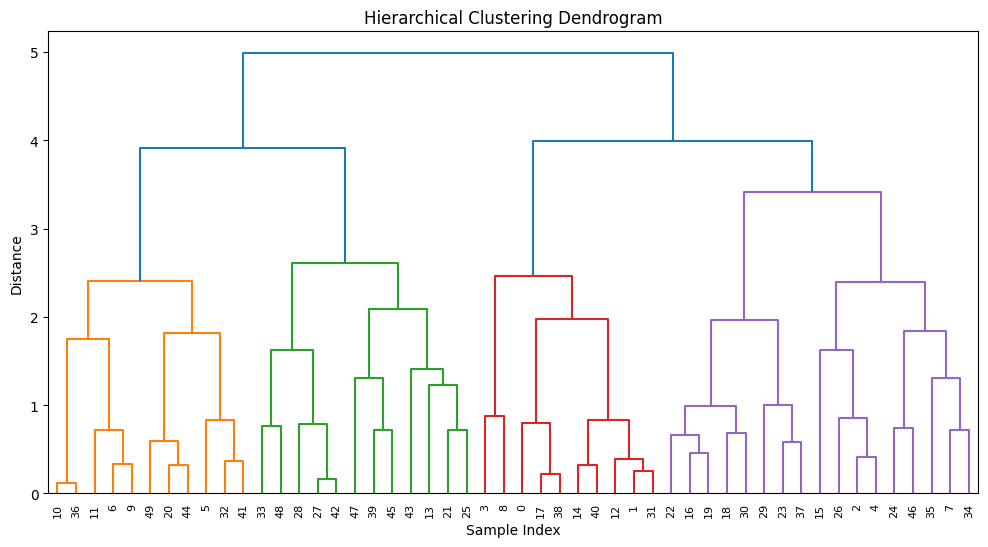

In [22]:
subset = X_scaled.sample(n=50, random_state=seed)
linkage_matrix = hierarchy.linkage(subset, method="ward")

plt.figure(figsize=(12, 6))
hierarchy.dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

## What's Next?

You are encouraged to experiment further:

- K-Means
  - Try different values of `n_clusters` based on the elbow plot

- DBSCAN
  - Adjust `eps` and `min_samples` to find optimal clusters

- AgglomerativeClustering
  - Compare how different linkage methods affect cluster quality
  - Try different numbers of clusters and observe the dendrogram

See this week's Canvas module for more information about when to use each clustering method and how to interpret clustering results.